In [2]:
import pandas as pd 
from sklearn.datasets import load_iris 
iris = load_iris() 

In [3]:
iris.feature_names


['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [4]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [7]:
df=pd.DataFrame(iris.data,columns=iris.feature_names)

In [8]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [9]:
df.shape


(150, 4)

In [10]:
df['target']=iris.target
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [11]:
#Lets locate versicolor as its number is 1 so
df[df.target==1].head()
#starting from 50 row

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
50,7.0,3.2,4.7,1.4,1
51,6.4,3.2,4.5,1.5,1
52,6.9,3.1,4.9,1.5,1
53,5.5,2.3,4.0,1.3,1
54,6.5,2.8,4.6,1.5,1


In [12]:
#Lets locate virginica as its number is 1 so
df[df.target==2].head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
100,6.3,3.3,6.0,2.5,2
101,5.8,2.7,5.1,1.9,2
102,7.1,3.0,5.9,2.1,2
103,6.3,2.9,5.6,1.8,2
104,6.5,3.0,5.8,2.2,2


In [13]:
# Now you may got an idea that from row 0 to 50 we have setaosa
# from row 50 to 100 we have versicolor ad from 100 to 150 we have verginica
# now split these categories
df0=df[:50]
df1=df[50:100]
df2=df[100:]

In [14]:
import matplotlib.pyplot as plt
%matplotlib inline

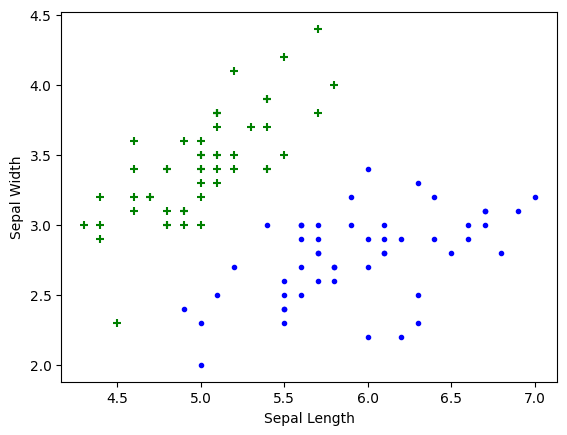

In [18]:
plt.xlabel('Sepal Length') 
plt.ylabel('Sepal Width')


plt.scatter(df0['sepal length (cm)'], df0['sepal width (cm)'], color="green", marker='+')
plt.scatter(df1['sepal length (cm)'], df1['sepal width (cm)'], color="blue", marker='.')

plt.show()

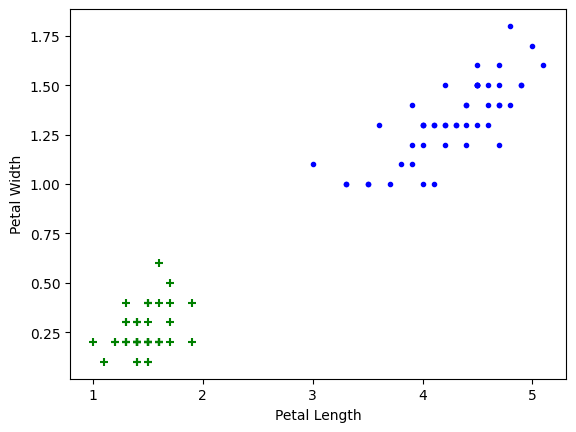

In [19]:
plt.xlabel('Petal Length') 
plt.ylabel('Petal Width')


plt.scatter(df0['petal length (cm)'], df0['petal width (cm)'], color="green", marker='+')
plt.scatter(df1['petal length (cm)'], df1['petal width (cm)'], color="blue", marker='.')

plt.show()

In [20]:
from sklearn.model_selection import train_test_split

In [24]:
X=df.drop(['target'],axis='columns')
y=df.target

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) 

In [28]:
len(X_train)

120

In [29]:
len(X_test)

30

### Create KNN classifier

In [40]:
#checking from google how to create knn classifier in sklearn
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=7) #

knn.fit(X_train, y_train) 

KNeighborsClassifier(n_neighbors=7)

In [41]:
knn.score(X_test,y_test)

0.9666666666666667

In [42]:
from sklearn.metrics import confusion_matrix 
y_pred = knn.predict(X_test) 
cm = confusion_matrix(y_test, y_pred)
cm 

array([[10,  0,  0],
       [ 0,  8,  1],
       [ 0,  0, 11]])

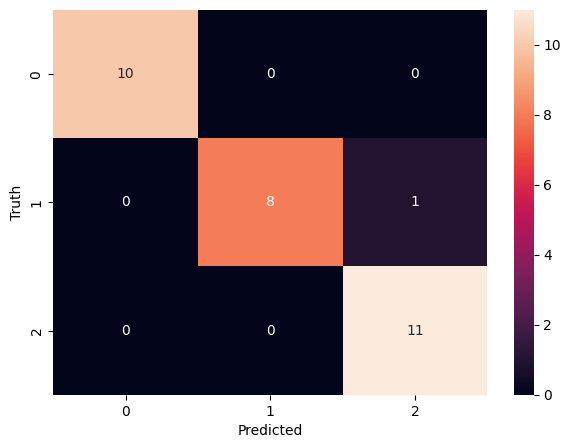

In [43]:
# For better visualization of confusion metrics
import seaborn as sns 

# Create a new figure with a specified size (width=7 inches, height=5 inches)
plt.figure(figsize=(7,5)) 
sns.heatmap(cm, annot=True) 
plt.xlabel('Predicted') 
plt.ylabel('Truth') 
plt.show() 








